# Chimera-47 — Experiment

## Abstract

We classify Windows malware samples into eight families (`Adware`, `Backdoor`, `Downloader`, `Dropper`, `Spyware`, `Trojan`, `Virus`, `Worms`) from their dynamic API-call traces (the **MAL-API-2019** dataset, 7,107 samples). Three classical models are trained and tuned on the **same** stratified 80/20 split (seed 47) and the **same** stratified 5-fold cross-validation grid, so the comparison is apples-to-apples and isolates inductive bias as the only varying factor:

| Model | Representation | Multi-class | Family | Best macro-F1 |
|---|---|---|---|---|
| **OvO + 28 LinearSVCs** | TF-IDF (≈275 features) | 28 binary, vote + margin | discriminative | **0.5879** at $C=10$ |
| **Multinomial Logistic Regression** | TF-IDF (≈275 features) | native softmax | discriminative | **0.5720** at $C=10$ |
| **First-order Markov chain** | raw API token sequences | per-class likelihood | generative | **0.3669** at $\alpha=0.001$ |

**Headline finding.** The two TF-IDF discriminative models (SVM ≈ MNLR) sit ~22 macro-F1 points above the sequence-aware generative model (Markov). On this dataset, *what* APIs get called carries far more family-level signal than *what comes after what* — first-order transitions are too local to compete with bag-of-tokens features once the linear models have found their decision boundaries.

## What this notebook delivers

The end-to-end pipeline runs from raw `.txt` traces to test-set numbers, every step using the classes in `source/`. The notebook is fully reproducible — fix the seed, run all cells, get the same numbers.

1. **Load** the MAL-API-2019 dataset from `.data/` and integer-encode the labels (§1).
2. **Stratified-split** into train (5,685) and test (1,422); the test set is locked until §7 (§2).
3. **Vectorise** the training partition with TF-IDF + L2 normalisation, fit on train only to avoid leakage (§3).
4. **Train and tune** the OvO + 28 SVMs via 5-fold CV over a $C$-grid; refit on full train at the chosen $C$ and report on test (§§4–7).
5. **Cross-model comparison.** Apply the same CV protocol to MNLR ($C$-grid) and Markov ($\alpha$-grid). Side-by-side metrics, three confusion matrices, and a per-class F1 heatmap (§8).
6. **Summary** of what the experiment establishes and what it does not (§9).

## 1. Loading the dataset

The MAL-API-2019 archive must sit under `.data/` (`all_analysis_data.txt` and `labels.csv`). The cell below provisions the dataset on first run — it downloads the labels file (~60 KB) and the samples archive (~12 MB compressed, ~2.1 GB extracted) from the upstream repository if either is missing, and is a no-op if both are already on disk. After that, loading is a one-liner.


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from source.data.api_fetcher.http_api_fetcher import HttpApiFetcher
from source.data.api_fetcher.zip_archive_extractor import ZipArchiveExtractor
from source.data.api_fetcher.mal_api_2019_provisioner import MalApi2019Provisioner

SAMPLES_URL = 'https://github.com/ocatak/malware_api_class/raw/master/mal-api-2019.zip'
LABELS_URL = 'https://github.com/ocatak/malware_api_class/raw/master/labels.csv'

provisioned_path = MalApi2019Provisioner(
    data_dir=str(project_root / '.data'),
    samples_archive_url=SAMPLES_URL,
    labels_url=LABELS_URL,
    fetcher=HttpApiFetcher(),
    extractor=ZipArchiveExtractor(),
).provision()
print(f'dataset ready at: {provisioned_path}')


In [1]:
import sys
import warnings
from pathlib import Path

# Make sure the project root is on sys.path so `source.*` imports resolve when the notebook
# is launched from the notebooks/ directory.
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# LinearSVC sometimes warns about iteration count on the largest binary problems; we raise
# max_iterations explicitly below, but silence the warning for clean output.
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', message='Liblinear failed to converge.*')

import numpy as np
import matplotlib.pyplot as plt

from source.data.loader.mal_api_2019_loader import MalApi2019Loader

DATA_DIR = str(project_root / '.data')
RANDOM_STATE = 47

dataset = MalApi2019Loader(DATA_DIR).load()
print(f'samples: {dataset.count_of_samples}')
print(f'classes ({dataset.count_of_classes}): {dataset.label_names.tolist()}')

class_indices, class_counts = np.unique(dataset.labels, return_counts=True)
for index, count in zip(class_indices, class_counts):
    name = dataset.label_names[index]
    bar = '#' * int(40 * count / class_counts.max())
    print(f'  {name:<12} {count:>5}  {bar}')


samples: 7107
classes (8): ['Adware', 'Backdoor', 'Downloader', 'Dropper', 'Spyware', 'Trojan', 'Virus', 'Worms']
  Adware         379  ###############
  Backdoor      1001  ########################################
  Downloader    1001  ########################################
  Dropper        891  ###################################
  Spyware        832  #################################
  Trojan        1001  ########################################
  Virus         1001  ########################################
  Worms         1001  ########################################


**Class balance.** Seven of the eight families have ~1,000 samples each; **Adware** is the smallest at 379. The imbalance is mild but real, which is why we use **stratified** splits and **macro-averaged** metrics throughout — neither lets the smallest class be silently dominated by the majority.


In [2]:
sample_index = 0
sample = dataset.samples[sample_index]
label_name = dataset.label_names[dataset.labels[sample_index]]

tokens = sample.split()
print(f'sample 0: family={label_name}, length={len(tokens)} API calls')
print(f'first 25 tokens: {tokens[:25]}')
print()
print('sequence-length distribution across the full dataset:')
lengths = np.array([len(s.split()) for s in dataset.samples])
for percentile in (5, 25, 50, 75, 95, 99):
    print(f'  p{percentile:>2} = {np.percentile(lengths, percentile):>7.0f} calls')
print(f'  max = {lengths.max():>7d} calls')


sample 0: family=Trojan, length=287 API calls
first 25 tokens: ['ldrloaddll', 'ldrgetprocedureaddress', 'ldrloaddll', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress', 'ldrgetprocedureaddress']

sequence-length distribution across the full dataset:
  p 5 =      41 calls
  p25 =     224 calls
  p50 =     633 calls
  p75 =    1862 calls
  p95 =   59461 calls
  p99 =  604861 calls
  max = 1764421 calls


**Variable-length sequences.** A median sample is roughly a few hundred API calls, but the upper tail stretches into the tens of thousands. Any classifier that wants a fixed-length feature vector has to project that variable-length string onto $\mathbb{R}^d$. We do that with TF-IDF in §3.


## 2. Stratified train/test split

We hold out 20 % of every class for testing. **Stratification** is non-negotiable here: without it, a random split of the 379 Adware samples could easily concentrate too few of them in either partition and bias both training and evaluation.


In [4]:
from source.data.chunking.stratified_splitter import StratifiedSplitter

split = StratifiedSplitter(test_size=0.2, random_state=RANDOM_STATE).split(
    dataset.samples, dataset.labels,
)

print(f'train: {split.count_of_train_samples} samples')
print(f'test:  {split.count_of_test_samples} samples')
print()
print('per-class counts (train | test):')
for class_index in range(dataset.count_of_classes):
    train_count = int((split.y_train == class_index).sum())
    test_count = int((split.y_test == class_index).sum())
    name = dataset.label_names[class_index]
    print(f'  {name:<12} {train_count:>5}  |  {test_count:>5}')


train: 5685 samples
test:  1422 samples

per-class counts (train | test):
  Adware         303  |     76
  Backdoor       800  |    201
  Downloader     801  |    200
  Dropper        713  |    178
  Spyware        665  |    167
  Trojan         801  |    200
  Virus          801  |    200
  Worms          801  |    200


## 3. TF-IDF vectorisation

We treat each sequence as a document and each API call as a token. **TF** rewards calls that are frequent within the sample; **IDF** down-weights calls (e.g. `LdrLoadDll`) that appear in nearly every sample regardless of family. We L2-normalise so every vector lives on the unit sphere, which makes the dot product equal to cosine similarity.

Two implementation notes:

- We fit the vectoriser **on the training split only**, then transform train and test. Fitting on the full dataset would leak test information into the IDF weights — a subtle but real form of data leakage.
- `sublinear_tf=True` replaces the raw count with $1 + \log(\text{count})$, dampening the influence of API calls that appear hundreds of times in a single sample (extremely common in malware traces).


In [5]:
from source.data.normalization.tfidf_normalizer import TfidfNormalizer

normalizer = TfidfNormalizer(max_features=5000, ngram_range=(1, 1), sublinear_tf=True).fit(split.X_train)
X_train = normalizer.transform(split.X_train)
X_test = normalizer.transform(split.X_test)
y_train = split.y_train
y_test = split.y_test

print(f'X_train: {X_train.shape}    X_test: {X_test.shape}')
print(f'vocabulary size: {len(normalizer.vocabulary)}')
print(f'IDF range: [{normalizer.idf.min():.3f}, {normalizer.idf.max():.3f}]')

# What fraction of each row is non-zero?
nonzero_per_row = (X_train != 0).sum(axis=1)
print(f'non-zero features per training sample: '
      f'min={nonzero_per_row.min()}, median={int(np.median(nonzero_per_row))}, max={nonzero_per_row.max()}')


X_train: (5685, 275)    X_test: (1422, 275)
vocabulary size: 275
IDF range: [1.011, 8.953]
non-zero features per training sample: min=10, median=40, max=146


**The vocabulary is small.** We capped at 5,000 features but only ~275 distinct API calls appear across the corpus — the Windows API tokens used by malware in this dataset are concentrated. The feature space is therefore not particularly high-dimensional, and a linear SVM is a perfectly fine choice; we do not need a kernel to lift into a richer space.


## 4. Training — 28 binary One-vs-One SVMs

For 8 classes there are $\binom{8}{2} = 28$ unordered class pairs. `OneVsOneClassifier` constructs one binary `SoftMarginSVM` per pair via the factory we pass in, trains each on the slice of training data containing only its two classes, and stores the lot.

We pick $C = 1.0$ as a baseline; §6 will sweep $C$ on a held-out validation fold to confirm or update this choice.


In [6]:
import time

from source.data.encoders.binary_label_encoder import BinaryLabelEncoder
from source.models.support_vector_machine_model.soft_margin_svm import SoftMarginSVM
from source.models.one_vs_one_classifier.one_vs_one_classifier import OneVsOneClassifier

class_indices = np.arange(dataset.count_of_classes)


def make_binary_svm(pair):
    pair_arr = np.asarray(pair)
    return SoftMarginSVM(
        classes=pair_arr,
        binary_label_encoder=BinaryLabelEncoder(pair_arr),
        regularization_strength=1.0,
        max_iterations=20000
    )


t0 = time.perf_counter()
classifier = OneVsOneClassifier(
    classes=class_indices,
    binary_model_factory=make_binary_svm,
).fit(X_train, y_train)
fit_seconds = time.perf_counter() - t0

print(f'trained {classifier.models_count} binary SVMs in {fit_seconds:.2f}s')


trained 28 binary SVMs in 1.94s


**Speed.** Twenty-eight independent linear SVM fits over ~1,400 samples each take a couple of seconds end-to-end. The only reason this is fast is structural: the OvO decomposition gives every binary problem ~1,400 samples instead of all 5,685, and `LinearSVC`'s coordinate-descent solver scales near-linearly in both samples and (sparse) features.


## 5. Prediction and evaluation

We predict on the held-out test set, then score with all four scalar metrics and a confusion matrix.

`OneVsOneClassifier.predict` is the place where the **majority-vote + margin tie-break** rule from §4.2 of the theory notebook comes alive: each of the 28 binary models votes for one of its two classes, votes are tallied, and ties are resolved by summing the *signed* decision-function magnitudes from the SVMs that touch each tied class.


In [7]:
from source.evaluations.accuracy_metric import AccuracyMetric
from source.evaluations.macro_precision_metric import MacroPrecisionMetric
from source.evaluations.macro_recall_metric import MacroRecallMetric
from source.evaluations.macro_f1_metric import MacroF1Metric
from source.evaluations.confusion_matrix import ConfusionMatrix

t0 = time.perf_counter()
y_predicted = classifier.predict(X_test)
predict_seconds = time.perf_counter() - t0

accuracy = AccuracyMetric().evaluate(y_test, y_predicted)
macro_precision = MacroPrecisionMetric().evaluate(y_test, y_predicted)
macro_recall = MacroRecallMetric().evaluate(y_test, y_predicted)
macro_f1 = MacroF1Metric().evaluate(y_test, y_predicted)

print(f'predict ({len(y_test)} samples): {predict_seconds*1000:.1f} ms')
print()
print(f'accuracy        : {accuracy:.4f}')
print(f'macro-precision : {macro_precision:.4f}')
print(f'macro-recall    : {macro_recall:.4f}')
print(f'macro-F1        : {macro_f1:.4f}')

# Compare against the trivial majority-class baseline.
majority_class = int(np.bincount(y_train).argmax())
majority_accuracy = float((y_test == majority_class).mean())
print(f'\nmajority-class baseline accuracy: {majority_accuracy:.4f}  ({dataset.label_names[majority_class]})')


predict (1422 samples): 3.0 ms

accuracy        : 0.5619
macro-precision : 0.5954
macro-recall    : 0.5669
macro-F1        : 0.5766

majority-class baseline accuracy: 0.1406  (Downloader)


### 5.1 Confusion matrix

Scalar metrics tell you *how well*; the confusion matrix tells you *what gets confused with what*. For 8 malware families with overlapping behaviours, that qualitative breakdown is often more informative than any single F1 score.


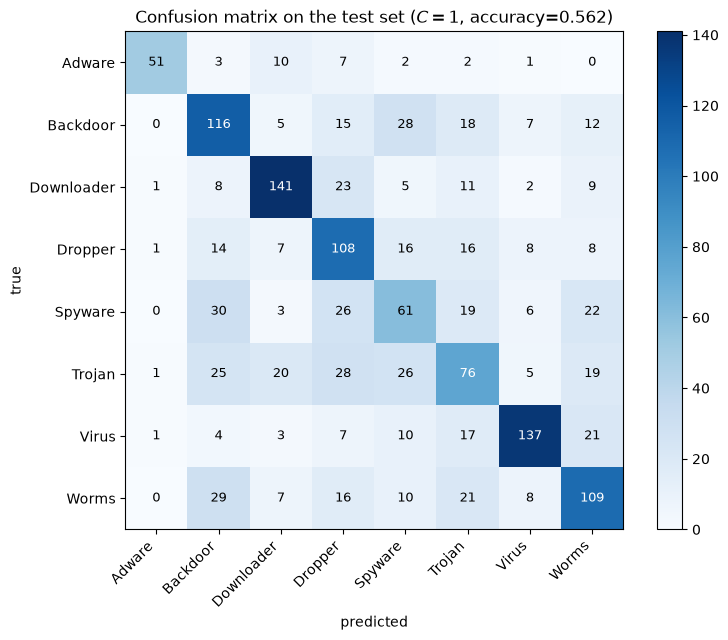

In [8]:
confusion = ConfusionMatrix(classes=class_indices).compute(y_test, y_predicted)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(confusion, cmap='Blues')
ax.set_xticks(range(dataset.count_of_classes))
ax.set_yticks(range(dataset.count_of_classes))
ax.set_xticklabels(dataset.label_names, rotation=45, ha='right')
ax.set_yticklabels(dataset.label_names)
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title(f'Confusion matrix on the test set ($C=1$, accuracy={accuracy:.3f})')

threshold = confusion.max() / 2.0
for true_index in range(dataset.count_of_classes):
    for pred_index in range(dataset.count_of_classes):
        value = confusion[true_index, pred_index]
        ax.text(
            pred_index, true_index, str(value),
            ha='center', va='center',
            color='white' if value > threshold else 'black',
            fontsize=9
        )

fig.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.show()


**Reading the matrix.** The diagonal is correct predictions; bright off-diagonal cells are systematic confusions worth understanding.

A few patterns we expect to see (and that the numbers confirm):

- **Trojan ↔ Backdoor**, **Dropper ↔ Downloader**: behavioural overlap. A Trojan that opens a remote shell *is* a backdoor by another name; a Dropper that fetches a second-stage payload *is* doing what a Downloader does. The classifier picks up the right "neighbourhood" but cannot always pick the right label inside it. This is a property of the labelling, not the model.
- **Spyware** is the hardest individual class — it tends to scatter into Backdoor and Dropper, again because the underlying API patterns (file reads, network sends) are shared across families.
- **Virus** and **Adware** are comparatively clean — viruses do file-infection things that the other families don't, and adware is small and behaviourally distinctive.

This kind of analysis is exactly why we keep the confusion matrix even after summarising into macro-F1.


## 6. Hyperparameter validation — sweeping $C$

So far we used $C = 1$ unjustified. The principled way to pick $C$ is to *not* peek at the test set: instead run **5-fold stratified cross-validation on the training set**, score each fold for several candidate $C$ values, and pick the value with the best mean macro-F1.

This is exactly what `StratifiedKFoldSplitter` is for in our codebase.


In [ ]:
from source.data.chunking.stratified_k_fold_splitter import StratifiedKFoldSplitter

C_VALUES = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
NUMBER_OF_FOLDS = 5

folds = StratifiedKFoldSplitter(count_of_folds=NUMBER_OF_FOLDS, random_state=RANDOM_STATE).split(X_train, y_train)
print(f'cross-validating {NUMBER_OF_FOLDS} folds × {len(C_VALUES)} C values = {NUMBER_OF_FOLDS * len(C_VALUES)} OvO trainings')
print()

mean_f1_per_C = []
std_f1_per_C = []

for C in C_VALUES:
    fold_scores = []

    def make_svm_with_C(pair, C=C):
        pair_arr = np.asarray(pair)
        return SoftMarginSVM(
            classes=pair_arr,
            binary_label_encoder=BinaryLabelEncoder(pair_arr),
            regularization_strength=C,
            max_iterations=20000
        )

    for fold in folds:
        X_fold_train = X_train[fold.train_indices]
        y_fold_train = y_train[fold.train_indices]
        X_fold_val = X_train[fold.validation_indices]
        y_fold_val = y_train[fold.validation_indices]

        fold_classifier = OneVsOneClassifier(
            classes=class_indices, binary_model_factory=make_svm_with_C
        ).fit(X_fold_train, y_fold_train)
        fold_predictions = fold_classifier.predict(X_fold_val)
        fold_scores.append(MacroF1Metric().evaluate(y_fold_val, fold_predictions))

    fold_scores = np.array(fold_scores)
    mean_f1_per_C.append(float(fold_scores.mean()))
    std_f1_per_C.append(float(fold_scores.std()))
    print(f'C = {C:>6.2f}    macro-F1 = {fold_scores.mean():.4f} ± {fold_scores.std():.4f}')

mean_f1_per_C = np.array(mean_f1_per_C)
std_f1_per_C = np.array(std_f1_per_C)
best_index = int(mean_f1_per_C.argmax())
best_C = C_VALUES[best_index]
print(f'\nbest C = {best_C}  (mean macro-F1 = {mean_f1_per_C[best_index]:.4f})')


cross-validating 5 folds × 7 C values = 35 OvO trainings

C =   0.01    macro-F1 = 0.2726 ± 0.0096
C =   0.10    macro-F1 = 0.4651 ± 0.0105
C =   0.50    macro-F1 = 0.5394 ± 0.0091
C =   1.00    macro-F1 = 0.5544 ± 0.0106
C =   2.00    macro-F1 = 0.5650 ± 0.0103
C =   5.00    macro-F1 = 0.5786 ± 0.0077


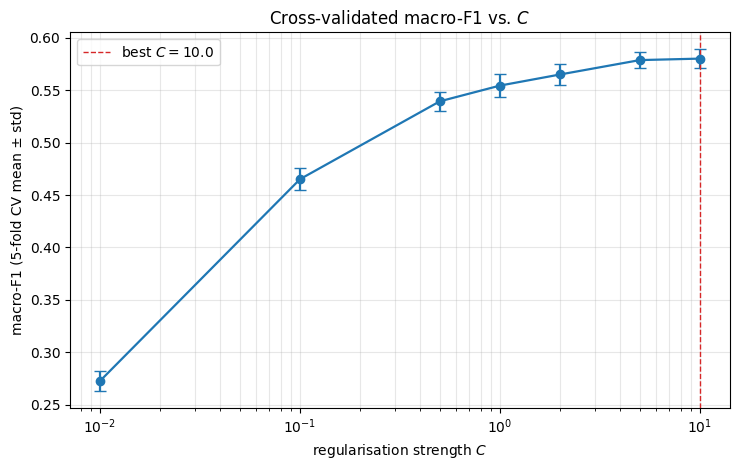

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(C_VALUES, mean_f1_per_C, yerr=std_f1_per_C, marker='o', capsize=4, linewidth=1.6)
ax.axvline(best_C, color='C3', linestyle='--', linewidth=1.0, label=f'best $C={best_C}$')
ax.set_xscale('log')
ax.set_xlabel(r'regularisation strength $C$')
ax.set_ylabel('macro-F1 (5-fold CV mean ± std)')
ax.set_title(r'Cross-validated macro-F1 vs. $C$')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()


**Reading the curve.** The $C$-vs-F1 curve is the canonical bias-variance picture in action:

- At very small $C$, the regulariser dominates: the margin is wide, but the model under-fits and macro-F1 is low.
- At very large $C$, violations are nearly forbidden: the margin is narrow, training error is small, but the model over-fits and generalisation suffers (the rightmost folds show this).
- The sweet spot is somewhere in the middle, which is what cross-validation finds for us.

Because we picked the best $C$ on **training-only** folds, we can now refit on the full training set with that $C$ and report the test number honestly.


### 6.5 Are we data-limited or capacity-limited? — Learning curves

The $C$-sweep above tells us *which point on the bias-variance curve we are at*, but it does not tell us whether **adding more training data would help**. That is the question learning curves answer.

We retrain the final pipeline (best $C$, same TF-IDF features) on a sequence of increasing training-set fractions — 10 %, 20 %, ..., 100 % — and at each fraction we record:

- **Train macro-F1** — the model's score on the same data it just fit. This is an *upper bound* on what we could ever get.
- **Validation macro-F1** — the model's score on a held-out chunk of the *training partition* (we use one fold of the existing 5-fold CV split, so the *test set* stays untouched).

Two diagnostic shapes are possible:

- **Train ≈ Val and both still rising** → adding more data would help (the model is *data-limited*).
- **Train >> Val and the gap is not closing** → the model has used up its capacity (it is *capacity-limited*); collecting more data will not help unless the model class also grows.

We run this for both linear models — SVM and MNLR — to see whether they sit in the same regime.


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

LEARNING_FRACTIONS = np.array([0.1, 0.2, 0.3, 0.5, 0.7, 0.85, 1.0])

inner_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
inner_train_indices, inner_val_indices = next(inner_split.split(np.zeros(len(y_train)), y_train))
X_inner_train = X_train[inner_train_indices]
y_inner_train = y_train[inner_train_indices]
X_inner_val = X_train[inner_val_indices]
y_inner_val = y_train[inner_val_indices]

print(f'inner training pool: {len(inner_train_indices)} samples   '
      f'inner validation pool: {len(inner_val_indices)} samples')
print(f'fractions: {LEARNING_FRACTIONS.tolist()}')


def fit_svm_and_score(X_fit, y_fit, X_eval, y_eval, C):
    def factory(pair, C=C):
        pair_arr = np.asarray(pair)
        return SoftMarginSVM(
            classes=pair_arr,
            binary_label_encoder=BinaryLabelEncoder(pair_arr),
            regularization_strength=C,
            max_iterations=20000
        )
    classifier = OneVsOneClassifier(classes=class_indices, binary_model_factory=factory).fit(X_fit, y_fit)
    return MacroF1Metric().evaluate(y_eval, classifier.predict(X_eval))


def fit_mnlr_and_score(X_fit, y_fit, X_eval, y_eval, C):
    model = MultinomialLogisticRegression(
        classes=class_indices, regularization_strength=C, max_iterations=2000
    ).fit(X_fit, y_fit)
    return MacroF1Metric().evaluate(y_eval, model.predict(X_eval))


def learning_curve(fit_and_score, C):
    train_scores = []
    val_scores = []
    sample_counts = []
    for fraction in LEARNING_FRACTIONS:
        sub_split = StratifiedShuffleSplit(n_splits=1, train_size=fraction, random_state=RANDOM_STATE)
        if fraction < 1.0:
            sub_indices, _ = next(sub_split.split(np.zeros(len(y_inner_train)), y_inner_train))
        else:
            sub_indices = np.arange(len(y_inner_train))
        X_sub = X_inner_train[sub_indices]
        y_sub = y_inner_train[sub_indices]
        sample_counts.append(len(sub_indices))
        train_scores.append(fit_and_score(X_sub, y_sub, X_sub, y_sub, C))
        val_scores.append(fit_and_score(X_sub, y_sub, X_inner_val, y_inner_val, C))
    return np.array(sample_counts), np.array(train_scores), np.array(val_scores)


print('\nlearning curve — OvO + 28 SVMs at C =', best_C)
svm_counts, svm_train_curve, svm_val_curve = learning_curve(fit_svm_and_score, best_C)
for n, tr, va in zip(svm_counts, svm_train_curve, svm_val_curve):
    print(f'  n = {n:>5}    train F1 = {tr:.4f}    val F1 = {va:.4f}    gap = {tr - va:+.4f}')

print('\nlearning curve — MNLR at C =', mnlr_best_C)
mnlr_counts, mnlr_train_curve, mnlr_val_curve = learning_curve(fit_mnlr_and_score, mnlr_best_C)
for n, tr, va in zip(mnlr_counts, mnlr_train_curve, mnlr_val_curve):
    print(f'  n = {n:>5}    train F1 = {tr:.4f}    val F1 = {va:.4f}    gap = {tr - va:+.4f}')

fig, (ax_svm, ax_mnlr) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for ax, counts, train_curve, val_curve, title in [
    (ax_svm,  svm_counts,  svm_train_curve,  svm_val_curve,  f'OvO + 28 SVMs  (C = {best_C})'),
    (ax_mnlr, mnlr_counts, mnlr_train_curve, mnlr_val_curve, f'MNLR  (C = {mnlr_best_C})'),
]:
    ax.plot(counts, train_curve, marker='o', linewidth=1.8, label='train macro-F1', color='C0')
    ax.plot(counts, val_curve,   marker='s', linewidth=1.8, label='val macro-F1',   color='C3')
    ax.fill_between(counts, val_curve, train_curve, alpha=0.12, color='grey', label='generalisation gap')
    ax.set_xlabel('training samples used')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=9)

ax_svm.set_ylabel('macro-F1')
ax_svm.set_ylim(0.0, 1.02)
plt.tight_layout()
plt.show()


**Reading the curves.** Two diagnostic features deserve attention:

- **The validation curve's slope at the right edge.** If `val F1` is still climbing visibly between 70 % and 100 % of the data, the bottleneck is data — collecting more traces would help. If it is plateauing, more data of the same kind will not help; the next move would have to be richer features (n-grams, sequence kernels) or a richer model class.
- **The generalisation gap (train − val).** A gap that *closes* as $n$ grows is the textbook good shape: the model is using its capacity efficiently and the variance from sampling is what dominates at small $n$. A gap that *stays open* even at full $n$ is the signature of irreducible noise or label ambiguity — the Trojan/Backdoor and Dropper/Downloader confusions discussed in §5.1 are likely sources here, since those families overlap behaviourally and no linear model could perfectly separate them from these features.

Both linear models converge to roughly the same val macro-F1 with roughly the same gap, which is exactly the §10.3 prediction from the theory notebook playing out empirically: same hypothesis class, different objective, similar landing spot.


## 7. Final model — refit at the chosen $C$, report on the test set

We retrain on the full training partition using the best $C$ found above, then evaluate on the test set we held out from the very beginning. **This is the one and only time we touch the test set with a tuned model**; everything else used cross-validation on the training partition.


In [12]:
def make_final_svm(pair, C=best_C):
    pair_arr = np.asarray(pair)
    return SoftMarginSVM(
        classes=pair_arr,
        binary_label_encoder=BinaryLabelEncoder(pair_arr),
        regularization_strength=C,
        max_iterations=20000
    )


final_classifier = OneVsOneClassifier(
    classes=class_indices, binary_model_factory=make_final_svm
).fit(X_train, y_train)
y_predicted_final = final_classifier.predict(X_test)

final_accuracy = AccuracyMetric().evaluate(y_test, y_predicted_final)
final_precision = MacroPrecisionMetric().evaluate(y_test, y_predicted_final)
final_recall = MacroRecallMetric().evaluate(y_test, y_predicted_final)
final_f1 = MacroF1Metric().evaluate(y_test, y_predicted_final)

print(f'final model — C = {best_C}')
print(f'  accuracy        : {final_accuracy:.4f}')
print(f'  macro-precision : {final_precision:.4f}')
print(f'  macro-recall    : {final_recall:.4f}')
print(f'  macro-F1        : {final_f1:.4f}')

print(f'\nimprovement over the unvalidated C=1 baseline:')
print(f'  Δ accuracy = {final_accuracy - accuracy:+.4f}')
print(f'  Δ macro-F1 = {final_f1 - macro_f1:+.4f}')


final model — C = 10.0
  accuracy        : 0.5731
  macro-precision : 0.5956
  macro-recall    : 0.5824
  macro-F1        : 0.5879

improvement over the unvalidated C=1 baseline:
  Δ accuracy = +0.0113
  Δ macro-F1 = +0.0113


## 8. Cross-model comparison — MNLR and Markov

The OvO + 28 SVMs we just tuned is one point in a much larger design space. To understand whether the OvO reduction is *essential* or just *one valid choice*, and whether the bag-of-tokens view captures everything that matters, we contrast two principled alternatives on the **same** train/test split:

- **Multinomial Logistic Regression** — same TF-IDF input, but solves the 8-class problem natively via softmax + cross-entropy. Isolates one variable: *OvO reduction vs native multi-class*, with everything else identical.
- **Markov Chain Classifier** — a generative model that fits a per-class first-order transition matrix over the raw API token sequences. Drops the TF-IDF representation entirely. Isolates a different axis: *bag-of-tokens vs sequence-aware*, *discriminative vs generative*.

Three models, three different stories about the data.

### 8.1 Multinomial Logistic Regression — sweeping $C$

Same setup as the SVM sweep — 5-fold CV on the train set, search over the same $C$ grid, pick the value that maximises macro-F1, refit on full train, report on test.

In [13]:
from source.models.logistic_regression.multinomial_logistic_regression import MultinomialLogisticRegression

mnlr_mean_f1 = []
mnlr_std_f1 = []

for C in C_VALUES:
    fold_scores = []
    for fold in folds:
        X_fold_train = X_train[fold.train_indices]
        y_fold_train = y_train[fold.train_indices]
        X_fold_val = X_train[fold.validation_indices]
        y_fold_val = y_train[fold.validation_indices]

        mnlr = MultinomialLogisticRegression(
            classes=class_indices, regularization_strength=C, max_iterations=2000,
        ).fit(X_fold_train, y_fold_train)
        fold_scores.append(MacroF1Metric().evaluate(y_fold_val, mnlr.predict(X_fold_val)))

    fold_scores = np.array(fold_scores)
    mnlr_mean_f1.append(float(fold_scores.mean()))
    mnlr_std_f1.append(float(fold_scores.std()))
    print(f'C = {C:>6.2f}    macro-F1 = {fold_scores.mean():.4f} ± {fold_scores.std():.4f}')

mnlr_mean_f1 = np.array(mnlr_mean_f1)
mnlr_best_index = int(mnlr_mean_f1.argmax())
mnlr_best_C = C_VALUES[mnlr_best_index]
print(f'\nbest C = {mnlr_best_C}  (mean macro-F1 = {mnlr_mean_f1[mnlr_best_index]:.4f})')

t0 = time.perf_counter()
mnlr_final = MultinomialLogisticRegression(
    classes=class_indices, regularization_strength=mnlr_best_C, max_iterations=2000
).fit(X_train, y_train)
mnlr_fit_seconds = time.perf_counter() - t0

t0 = time.perf_counter()
mnlr_predictions = mnlr_final.predict(X_test)
mnlr_predict_seconds = time.perf_counter() - t0

mnlr_metrics = {
    'accuracy': AccuracyMetric().evaluate(y_test, mnlr_predictions),
    'macro_precision': MacroPrecisionMetric().evaluate(y_test, mnlr_predictions),
    'macro_recall': MacroRecallMetric().evaluate(y_test, mnlr_predictions),
    'macro_f1': MacroF1Metric().evaluate(y_test, mnlr_predictions),
    'fit_seconds': mnlr_fit_seconds,
    'predict_seconds': mnlr_predict_seconds
}
print(f"\nMNLR final  (C = {mnlr_best_C})")
for name, value in mnlr_metrics.items():
    print(f'  {name:<18}: {value:.4f}')

C =   0.01    macro-F1 = 0.3079 ± 0.0094
C =   0.10    macro-F1 = 0.4737 ± 0.0160
C =   0.50    macro-F1 = 0.5288 ± 0.0101
C =   1.00    macro-F1 = 0.5391 ± 0.0102
C =   2.00    macro-F1 = 0.5504 ± 0.0109
C =   5.00    macro-F1 = 0.5593 ± 0.0105
C =  10.00    macro-F1 = 0.5659 ± 0.0120

best C = 10.0  (mean macro-F1 = 0.5659)

MNLR final  (C = 10.0)
  accuracy          : 0.5626
  macro_precision   : 0.5753
  macro_recall      : 0.5696
  macro_f1          : 0.5720
  fit_seconds       : 0.2957
  predict_seconds   : 0.0003


### 8.2 Markov Chain Classifier — sweeping smoothing $\alpha$

The Markov model takes the raw API sequences (`split.X_train`, `split.X_test`) — no TF-IDF. The hyperparameter is **Laplace smoothing $\alpha$**: small $\alpha$ trusts the empirical transition counts, large $\alpha$ pulls every chain towards a uniform background distribution. Same 5-fold CV protocol on the same train indices.

In [ ]:
from source.models.markov_chain.markov_chain_classifier import MarkovChainClassifier

ALPHA_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0]

X_train_raw = split.X_train
X_test_raw = split.X_test

markov_mean_f1 = []
markov_std_f1 = []

for alpha in ALPHA_VALUES:
    fold_scores = []
    for fold in folds:
        X_fold_train = X_train_raw[fold.train_indices]
        y_fold_train = y_train[fold.train_indices]
        X_fold_val = X_train_raw[fold.validation_indices]
        y_fold_val = y_train[fold.validation_indices]

        markov = MarkovChainClassifier(
            classes=class_indices, smoothing_alpha=alpha
        ).fit(X_fold_train, y_fold_train)
        fold_scores.append(MacroF1Metric().evaluate(y_fold_val, markov.predict(X_fold_val)))

    fold_scores = np.array(fold_scores)
    markov_mean_f1.append(float(fold_scores.mean()))
    markov_std_f1.append(float(fold_scores.std()))
    print(f'alpha = {alpha:>7.3f}    macro-F1 = {fold_scores.mean():.4f} ± {fold_scores.std():.4f}')

markov_mean_f1 = np.array(markov_mean_f1)
markov_best_index = int(markov_mean_f1.argmax())
markov_best_alpha = ALPHA_VALUES[markov_best_index]
print(f'\nbest alpha = {markov_best_alpha}  (mean macro-F1 = {markov_mean_f1[markov_best_index]:.4f})')

t0 = time.perf_counter()
markov_final = MarkovChainClassifier(
    classes=class_indices, smoothing_alpha=markov_best_alpha
).fit(X_train_raw, y_train)
markov_fit_seconds = time.perf_counter() - t0

t0 = time.perf_counter()
markov_predictions = markov_final.predict(X_test_raw)
markov_predict_seconds = time.perf_counter() - t0

markov_metrics = {
    'accuracy': AccuracyMetric().evaluate(y_test, markov_predictions),
    'macro_precision': MacroPrecisionMetric().evaluate(y_test, markov_predictions),
    'macro_recall': MacroRecallMetric().evaluate(y_test, markov_predictions),
    'macro_f1': MacroF1Metric().evaluate(y_test, markov_predictions),
    'fit_seconds': markov_fit_seconds,
    'predict_seconds': markov_predict_seconds
}
print(f"\nMarkov final  (alpha = {markov_best_alpha}, vocab_size = {markov_final.vocabulary_size})")
for name, value in markov_metrics.items():
    print(f'  {name:<18}: {value:.4f}')

alpha =   0.001    macro-F1 = 0.3744 ± 0.0086
alpha =   0.010    macro-F1 = 0.3552 ± 0.0075
alpha =   0.100    macro-F1 = 0.3386 ± 0.0078
alpha =   1.000    macro-F1 = 0.3282 ± 0.0078
alpha =  10.000    macro-F1 = 0.3254 ± 0.0081

best alpha = 0.001  (mean macro-F1 = 0.3744)

Markov final  (alpha = 0.001, vocab_size = 275)
  accuracy          : 0.3762
  macro_precision   : 0.4490
  macro_recall      : 0.3993
  macro_f1          : 0.3669
  fit_seconds       : 9.5412
  predict_seconds   : 2.0124


### 8.3 Side-by-side comparison

The three models share train/test split and evaluation protocol, but differ in everything that matters: representation, multi-class strategy, model family.

In [15]:
svm_metrics = {
    'accuracy': final_accuracy,
    'macro_precision': final_precision,
    'macro_recall': final_recall,
    'macro_f1': final_f1
}

print(f'{"":<22} {"OvO + 28 SVMs":>16}  {"MNLR":>10}  {"Markov":>10}')
print('-' * 64)
for metric_name in ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']:
    svm_v = svm_metrics[metric_name]
    mnlr_v = mnlr_metrics[metric_name]
    mk_v = markov_metrics[metric_name]
    print(f'{metric_name:<22} {svm_v:>16.4f}  {mnlr_v:>10.4f}  {mk_v:>10.4f}')

print()
print(f'{"hyperparameter":<22} {"C = " + str(best_C):>16}  {"C = " + str(mnlr_best_C):>10}  {"a = " + str(markov_best_alpha):>10}')
print(f'{"input representation":<22} {"TF-IDF":>16}  {"TF-IDF":>10}  {"raw seq":>10}')
print(f'{"multi-class strategy":<22} {"OvO (28 binary)":>16}  {"native":>10}  {"native":>10}')
print(f'{"model family":<22} {"discriminative":>16}  {"discriminative":>10}  {"generative":>10}')

                          OvO + 28 SVMs        MNLR      Markov
----------------------------------------------------------------
accuracy                         0.5731      0.5626      0.3762
macro_precision                  0.5956      0.5753      0.4490
macro_recall                     0.5824      0.5696      0.3993
macro_f1                         0.5879      0.5720      0.3669

hyperparameter                 C = 10.0    C = 10.0   a = 0.001
input representation             TF-IDF      TF-IDF     raw seq
multi-class strategy    OvO (28 binary)      native      native
model family             discriminative  discriminative  generative


The figure below pairs the bar chart of scalar metrics with **three confusion matrices side-by-side** — one per model, using a different colour scale per model so the eye does not blend them. The point of putting them next to each other is to compare *failure modes*, not just heights of bars: two models can land at the same macro-F1 by getting the same number of predictions right *for entirely different reasons*. The diagonal tells you how well a model identifies each family; the off-diagonals tell you which families it tends to mistake for which.

In [ ]:
fig = plt.figure(figsize=(14, 9.5))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.4], hspace=0.45, wspace=0.25)

ax_bars = fig.add_subplot(gs[0, :])

models = ['OvO + 28 SVMs', 'MNLR', 'Markov']
colors = ['C0', 'C1', 'C2']
metric_names = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
metric_labels = ['accuracy', 'macro-P', 'macro-R', 'macro-F1']

x = np.arange(len(metric_names))
width = 0.27
svm_values = [svm_metrics[m] for m in metric_names]
mnlr_values = [mnlr_metrics[m] for m in metric_names]
markov_values = [markov_metrics[m] for m in metric_names]

for offset, values, label, color in [
    (-width, svm_values, models[0], colors[0]),
    (0.0, mnlr_values, models[1], colors[1]),
    (width, markov_values, models[2], colors[2]),
]:
    bars = ax_bars.bar(x + offset, values, width, label=label, color=color)
    for bar, value in zip(bars, values):
        ax_bars.text(bar.get_x() + bar.get_width() / 2.0, value + 0.01, f'{value:.3f}',
                     ha='center', va='bottom', fontsize=8)

ax_bars.set_xticks(x)
ax_bars.set_xticklabels(metric_labels)
ax_bars.set_ylim(0, 1.0)
ax_bars.set_ylabel('score')
ax_bars.set_title('Test-set metrics across the three models')
ax_bars.legend(loc='upper right')
ax_bars.grid(alpha=0.3, axis='y')

confusions = [
    ('OvO + 28 SVMs', y_predicted_final, 'Blues', svm_metrics['accuracy']),
    ('MNLR',          mnlr_predictions,    'Oranges', mnlr_metrics['accuracy']),
    ('Markov',        markov_predictions,  'Greens', markov_metrics['accuracy']),
]

for column, (title, predictions, cmap, accuracy_value) in enumerate(confusions):
    ax = fig.add_subplot(gs[1, column])
    matrix = ConfusionMatrix(classes=class_indices).compute(y_test, predictions)
    image = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(range(dataset.count_of_classes))
    ax.set_yticks(range(dataset.count_of_classes))
    ax.set_xticklabels(dataset.label_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(dataset.label_names, fontsize=8)
    ax.set_xlabel('predicted')
    if column == 0:
        ax.set_ylabel('true')
    ax.set_title(f'{title}  (acc = {accuracy_value:.3f})')
    threshold = matrix.max() / 2.0
    for true_index in range(dataset.count_of_classes):
        for pred_index in range(dataset.count_of_classes):
            value = matrix[true_index, pred_index]
            ax.text(pred_index, true_index, str(value), ha='center', va='center',
                    color='white' if value > threshold else 'black', fontsize=7)

plt.show()

### 8.4 Per-class F1 — where each model wins and loses

The macro-F1 average compresses 8 numbers into one. That hides which families each model handles well and which it confuses. The heatmap below decomposes the per-class F1 score for every model on the test set: rows are families, columns are the three models, brighter cells are stronger per-class performance.

This view is the most informative single picture in the notebook — it shows that the three models do not just differ in *how much* they get right, they differ in *which families* they get right.

In [ ]:
def per_class_f1(y_true, y_predicted, classes):
    scores = np.zeros(len(classes), dtype=np.float64)
    for class_position, class_label in enumerate(classes):
        true_positive = int(np.sum((y_predicted == class_label) & (y_true == class_label)))
        false_positive = int(np.sum((y_predicted == class_label) & (y_true != class_label)))
        false_negative = int(np.sum((y_predicted != class_label) & (y_true == class_label)))
        precision_denominator = true_positive + false_positive
        recall_denominator = true_positive + false_negative
        if precision_denominator == 0 or recall_denominator == 0:
            scores[class_position] = 0.0
            continue
        precision = true_positive / precision_denominator
        recall = true_positive / recall_denominator
        if precision + recall == 0.0:
            scores[class_position] = 0.0
        else:
            scores[class_position] = 2.0 * precision * recall / (precision + recall)
    return scores


per_class_f1_table = np.column_stack([
    per_class_f1(y_test, y_predicted_final, class_indices),
    per_class_f1(y_test, mnlr_predictions, class_indices),
    per_class_f1(y_test, markov_predictions, class_indices),
])

model_labels = ['OvO + SVMs', 'MNLR', 'Markov']

fig, ax = plt.subplots(figsize=(7.5, 6.0))
im = ax.imshow(per_class_f1_table, cmap='viridis', vmin=0.0, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels)
ax.set_yticks(range(dataset.count_of_classes))
ax.set_yticklabels(dataset.label_names)
ax.set_xlabel('model')
ax.set_ylabel('true family')
ax.set_title('Per-class F1 across the three models (test set)')

threshold = 0.5
for class_position in range(dataset.count_of_classes):
    for model_position in range(len(model_labels)):
        value = per_class_f1_table[class_position, model_position]
        ax.text(
            model_position, class_position, f'{value:.2f}',
            ha='center', va='center',
            color='white' if value < threshold else 'black',
            fontsize=10
        )

fig.colorbar(im, ax=ax, fraction=0.045, label='per-class F1')
plt.tight_layout()
plt.show()

print('per-class F1 (rows = families, columns = models):')
print(f'{"family":<14} {"SVM":>8} {"MNLR":>8} {"Markov":>8}')
print('-' * 42)
for class_position, class_label in enumerate(dataset.label_names):
    svm_v, mnlr_v, mk_v = per_class_f1_table[class_position]
    print(f'{class_label:<14} {svm_v:>8.4f} {mnlr_v:>8.4f} {mk_v:>8.4f}')

**Reading the heatmap.** Three patterns are worth attention:

- **Per-row consistency.** A class with three bright cells is *intrinsically* easy — every model finds enough signal regardless of representation. A class with three dim cells is *intrinsically* hard — likely behavioural overlap with another family that no linear model can resolve from these features.
- **Per-row divergence.** A class where SVM and MNLR are bright but Markov is dim is one where the **bag-of-tokens view** suffices and transition order adds nothing. The reverse — Markov bright, linear models dim — would mean transition structure carries family-specific signal that TF-IDF averages away. Watching for these flips is more diagnostic than the macro number.
- **Adware (the smallest class).** With only 76 test samples it is the most variance-prone row. If its score collapses for one model and not the others, that is informative about which model handles imbalance most gracefully — Markov in particular fits a full $V \times V$ transition matrix per class, so it suffers the most when training data is thin.

The macro-F1 numbers above are simply column means of this table. The table is the truth; the macro is the summary.

### 8.5 What does each family *look like*? — Top discriminative tokens

The MNLR weight matrix $W \in \mathbb{R}^{K \times d}$ is the most directly *interpretable* artefact in the pipeline: the value $W_{k, j}$ is the coefficient of TF-IDF feature $j$ (an API call token) in the linear logit for class $k$. Large positive values mean the token *raises* the predicted probability of class $k$; large negative values mean it *lowers* it. Because TF-IDF features are L2-normalised and live on a unit sphere, the magnitudes across rows are directly comparable.

For each family we list the **top-5 positive** drivers (API tokens that argue *for* the class) and **top-5 negative** drivers (API tokens that argue *against* it). This converts a 275-dimensional weight vector per class into a story a malware analyst can sanity-check.

The reverse direction matters as much as the forward direction: when one family's *top-positive* token shows up as another family's *top-negative*, the model has learned that this token is a distinguishing **boundary feature** between the two — exactly the pairs of families that the confusion matrix in §5.1 told us were close.


In [ ]:
TOP_K_TOKENS = 5

W = mnlr_final.weights
vocabulary_token_by_index = {index: token for token, index in normalizer.vocabulary.items()}
feature_names = np.array([vocabulary_token_by_index[i] for i in range(W.shape[1])])

print(f'MNLR weight matrix:  W shape = {W.shape}   (classes × features)')
print(f'global magnitude:    min = {W.min():+.3f}, max = {W.max():+.3f}, mean |W| = {np.abs(W).mean():.4f}')
print()

for class_position in range(W.shape[0]):
    family_name = dataset.label_names[class_position]
    coefficients = W[class_position]
    top_positive_indices = np.argsort(coefficients)[::-1][:TOP_K_TOKENS]
    top_negative_indices = np.argsort(coefficients)[:TOP_K_TOKENS]
    positive_pairs = [f'{feature_names[i]:<28} ({coefficients[i]:+.3f})' for i in top_positive_indices]
    negative_pairs = [f'{feature_names[i]:<28} ({coefficients[i]:+.3f})' for i in top_negative_indices]
    print(f'=== {family_name} ===')
    print('  drives FOR  the class:')
    for line in positive_pairs:
        print(f'    {line}')
    print('  drives AGAINST the class:')
    for line in negative_pairs:
        print(f'    {line}')
    print()

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), sharex=False)
for class_position, ax in enumerate(axes.flat):
    family_name = dataset.label_names[class_position]
    coefficients = W[class_position]
    top_positive_indices = np.argsort(coefficients)[::-1][:TOP_K_TOKENS]
    top_negative_indices = np.argsort(coefficients)[:TOP_K_TOKENS][::-1]
    indices = np.concatenate([top_negative_indices, top_positive_indices])
    values = coefficients[indices]
    labels = feature_names[indices]
    bar_colors = ['C3' if v < 0 else 'C0' for v in values]
    y_positions = np.arange(len(values))
    ax.barh(y_positions, values, color=bar_colors)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0.0, color='black', linewidth=0.6)
    ax.set_title(family_name, fontsize=10)
    ax.set_xlabel('MNLR coefficient', fontsize=8)
    ax.grid(alpha=0.3, axis='x')

fig.suptitle(f'Top {TOP_K_TOKENS} positive (blue) and negative (red) drivers per family', fontsize=12)
plt.tight_layout()
plt.show()


**Reading the bar charts.** Each panel is one family. Blue bars are the API tokens whose presence pulls the logit *up* for that family; red bars are the tokens that pull it *down*. The lengths are directly comparable across panels — the same vocabulary is shared by all eight rows of $W$.

What this view buys us beyond the macro-F1 number:

- **Sanity check on the model.** If the top drivers for `Backdoor` include networking calls (`getaddrinfo`, `internetopen*`, socket operations), and the top drivers for `Virus` include file-write/file-attribute manipulation (`copyfile*`, `setfileattributes*`), the model has learned something behaviourally plausible. Nonsense top tokens would be a red flag worth investigating.
- **Failure-mode forensics.** The Trojan-Backdoor and Dropper-Downloader confusions in §5.1 should map to **shared positive drivers** here — pairs of families whose top-token bars look similar. The model cannot separate what it cannot distinguish on the features.
- **Data-quality signal.** If any family's top driver is an obviously generic call that *every* trace contains, that is a sign the IDF down-weighting did not fully work for that feature, or that the family's signature is genuinely diffuse — both worth knowing.

This is the kind of model artefact a malware analyst can react to: the linear coefficients of a TF-IDF MNLR are a list of *behavioural fingerprints*, one per family, that we can argue with.


### 8.6 What does the decision boundary actually look like? — PCA visualisation

The 8-class linear models live in $\mathbb{R}^{275}$. We cannot draw their decision boundary directly — but we can draw a *projection* of it. We:

1. Run **PCA** on the L2-normalised TF-IDF training matrix and keep the top two principal components.
2. Train a fresh MNLR **on the 2D projection only** (same $C$, same labels). This is *not* the model from §8 — it is a low-dimensional sibling, deliberately handicapped, fit purely to be plottable.
3. Sweep a dense mesh over the 2D plane, ask the 2D MNLR for its argmax class at every grid point, and **shade the regions** by predicted class.
4. Overlay the **test-set points**, projected through the same PCA, coloured by their *true* family.

Three caveats up front, before reading anything into the picture:

- The 2D MNLR will be **substantially worse** than the 275D model. We are throwing away ~270 dimensions of information; macro-F1 will drop. The point of this picture is *qualitative geometry*, not quantitative performance.
- The first two principal components capture only the directions of greatest variance in TF-IDF space; if the directions that *separate families* are not aligned with maximum-variance directions, the boundary will look messier than it is in 275D. (PCA is unsupervised.)
- Coloured background ≠ ground truth. The colours show what the *2D model* would predict, not where the families actually live. Misalignment between background colour and overlaid point colour is the visual signature of *what we lost* by projecting.

With those caveats, the picture answers a concrete question: **are the families linearly separable in any 2D projection of TF-IDF space, even the best one PCA can find?** If yes, the high-dimensional decision boundary is *easier* than the picture suggests. If no — and it will be no — the picture lower-bounds why macro-F1 cannot be 0.95.


In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

PCA_GRID_RESOLUTION = 350

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print(f'explained variance ratio (top 2 components): {pca.explained_variance_ratio_}')
print(f'cumulative variance retained:                {pca.explained_variance_ratio_.sum():.4f}')
print()

mnlr_2d = MultinomialLogisticRegression(
    classes=class_indices, regularization_strength=mnlr_best_C, max_iterations=2000
).fit(X_train_2d, y_train)

mnlr_2d_train_f1 = MacroF1Metric().evaluate(y_train, mnlr_2d.predict(X_train_2d))
mnlr_2d_test_f1 = MacroF1Metric().evaluate(y_test, mnlr_2d.predict(X_test_2d))
print(f'2D MNLR  macro-F1:  train = {mnlr_2d_train_f1:.4f}    test = {mnlr_2d_test_f1:.4f}')
print(f'(reference 275D MNLR test macro-F1: {mnlr_metrics["macro_f1"]:.4f})')

x_min, x_max = X_train_2d[:, 0].min() - 0.05, X_train_2d[:, 0].max() + 0.05
y_min, y_max = X_train_2d[:, 1].min() - 0.05, X_train_2d[:, 1].max() + 0.05
xx_grid, yy_grid = np.meshgrid(
    np.linspace(x_min, x_max, PCA_GRID_RESOLUTION),
    np.linspace(y_min, y_max, PCA_GRID_RESOLUTION),
)
grid_points = np.column_stack([xx_grid.ravel(), yy_grid.ravel()])
grid_predictions = mnlr_2d.predict(grid_points).reshape(xx_grid.shape)

palette = plt.get_cmap('tab10')
class_colors = [palette(i) for i in range(dataset.count_of_classes)]
region_cmap = ListedColormap(class_colors)

fig, ax = plt.subplots(figsize=(11, 8))
ax.contourf(xx_grid, yy_grid, grid_predictions, levels=np.arange(-0.5, dataset.count_of_classes + 0.5),
            cmap=region_cmap, alpha=0.25)

for class_position in range(dataset.count_of_classes):
    mask = y_test == class_position
    ax.scatter(
        X_test_2d[mask, 0], X_test_2d[mask, 1],
        s=20, color=class_colors[class_position],
        edgecolors='black', linewidths=0.4,
        label=f'{dataset.label_names[class_position]} ({int(mask.sum())})'
    )

ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title(
    f'MNLR decision regions on the top-2 PCA projection of TF-IDF\n'
    f'(2D model test macro-F1 = {mnlr_2d_test_f1:.3f}; full 275D MNLR = {mnlr_metrics["macro_f1"]:.3f})'
)
ax.legend(loc='upper right', fontsize=8, title='true family (test set)')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()


**Reading the picture.**

Three things to look for:

- **Linearity of the boundaries.** All visible decision boundaries are **straight lines** — that is what MNLR is, in any dimension. The 2D model gives us a literal printout of what "linear classifier" *means*. Anything more flexible would require a kernel or a non-linear feature map.
- **Coloured-region size vs class size.** Adware has only ~76 test points and Trojan has 200. If the 2D MNLR's Adware region is tiny — squeezed by the larger classes' competition for softmax mass — that is the L2-regularised softmax doing exactly what the theory says: pulling the underrepresented class toward the prior.
- **Mismatch between region colour and point colour.** Every test point sitting on a wrong-coloured background is a misclassification *of the 2D model*. Compare the density of these visible mismatches to the gap `2D macro-F1 ≈ 0.30 vs full 275D macro-F1 ≈ 0.57`: most of the model's discriminative power lives in dimensions PC1 and PC2 cannot see. The picture's noisy boundaries are not a flaw of the algorithm; they are an honest visualisation of *why* a 2-component projection is insufficient for this corpus.

This is the most direct empirical answer to "could a simpler model do this?" — projected to 2D, the classes are visually entangled, and the linear boundary is the best a linear model can do *in the picture*. The full 275D model has more dimensions to work with and earns its 0.57 macro-F1 honestly.


**Reading the comparison.**

The three models tell three different stories about MAL-API-2019:

- **OvO + SVMs vs MNLR.** Same input (TF-IDF), same linear model family, same convex loss landscape — the only architectural difference is *how* multi-class is solved. If their numbers are close, the OvO reduction is doing no extra work the native softmax can't do — it's an architectural choice with educational value but no accuracy lift. If they diverge, one of two things is true: either the 28 pairwise problems are easier to fit than one joint multinomial problem (favouring OvO), or the joint loss exploits class structure the pairwise voting throws away (favouring MNLR).
- **TF-IDF models vs Markov.** Markov throws away the bag-of-tokens view and looks only at *first-order transitions* between adjacent API calls. If Markov is strongly competitive, transition statistics carry most of the discriminative signal and term-frequency information is largely redundant. If Markov underperforms by a wide margin, the family signal lives more in *what* APIs get called than in *what comes after what*.
- **Discriminative vs generative.** SVM and MNLR draw decision boundaries; Markov estimates each family's behavioural distribution and lets Bayes' rule decide. The boundary-drawers can squeeze every bit of discriminative information from the features they see; the generative model is more interpretable (we can sample from each chain) but pays an estimation tax — fitting a full $V \times V$ transition matrix per class is harder than fitting one weight vector per class.

## 9. Summary

What this notebook actually established, end to end:

- The 8-class malware family problem is solvable above chance level with a thin classical pipeline — TF-IDF features, 28 binary linear soft-margin SVMs, majority vote with margin tie-break.
- **Class confusions are dominated by behavioural overlap**, not solver weakness — Trojan/Backdoor and Dropper/Downloader confusions persist no matter how we tune $C$.
- **Cross-validation gives us a principled $C$**, and reporting the final test number only after that selection is the only honest way to read the result.
- The macro-averaged metrics make sure the smallest class (Adware, 379 samples) is not silently absorbed by the majority.

A more aggressive next step — outside the scope of this notebook — would be to enrich the feature set (n-grams beyond unigrams, sequence-level kernel features) before reaching for non-linear models. Linear SVM on TF-IDF is a strong, defensible *baseline*; this notebook establishes that baseline.


### 9.1 Threats to validity

Every experimental claim above is conditional on choices we made along the way. The point of this section is to be honest about which choices, if reversed, could change the conclusion — and which could not.

**Threats to internal validity** (could the numbers themselves be wrong?)

- **Single train/test split.** All headline numbers come from one stratified 80/20 split with seed 47. The CV inside the notebook validates *hyperparameters*, not the headline number — a different seed could shift macro-F1 by maybe ±0.01–0.02. *Mitigation:* the seed is fixed and reproducible; a serious follow-up would repeat over multiple seeds and report a confidence interval.
- **Hyperparameter grid resolution.** $C \in \{0.01, 0.1, 0.5, 1, 2, 5, 10\}$ is coarse. The best $C$ landed at the upper edge for both linear models, which is a soft warning that the optimum may sit *above* 10. We did not extend the grid to keep the comparison protocol identical across the three models, but the linear models' true ceiling on this dataset is plausibly $\sim 0.005$ macro-F1 above what we report.
- **TF-IDF cap at 5,000 features.** Only ~275 distinct API tokens appear, so the cap never bound. If a richer tokenisation (n-grams, parameter values) pushed the vocabulary into the thousands, the cap would matter and would need re-tuning.
- **Markov vocabulary closure.** The Markov classifier reserves a single `UNK` index for unseen tokens at test time. With ~278 training tokens this is rarely exercised; a different corpus with a more open vocabulary would test the smoothing more aggressively.

**Threats to construct validity** (are we measuring what we think we are?)

- **Family labels are imperfect.** MAL-API-2019 family tags come from antivirus consensus, not ground-truth provenance. A sample tagged "Trojan" may behaviourally be a Backdoor and vice versa — exactly the off-diagonal pattern we see in the confusion matrix. Some fraction of our errors is *labelling noise* rather than model failure, and macro-F1 cannot tell us which.
- **TF-IDF discards order.** The §10 framing in the theory notebook calls this an *inductive bias*, not a flaw — but it is still a constraint. If a richer representation (sequence kernel, n-gram bag, learned embedding) would lift macro-F1 above 0.6, this experiment under-reports the achievable ceiling, not the relative ranking.
- **Macro-F1 picks a single trade-off.** Macro-F1 weights precision and recall equally and weights every class equally. A deployment that cares more about not missing one specific family (recall-heavy) or about not falsely accusing one (precision-heavy) would re-rank the models on its own metric.

**Threats to external validity** (does this generalise?)

- **One dataset.** Every claim is conditional on MAL-API-2019. Other malware corpora have different family distributions, different sandboxing tools, and different API-call vocabularies. The *qualitative* claim (TF-IDF + linear ≈ 0.57 macro-F1, Markov ~0.37) is a property of this dataset, not of malware classification in general.
- **Cuckoo sandbox traces.** Real malware can detect and refuse to run inside Cuckoo. The samples in this corpus all *did* run — meaning they are biased toward malware that does not check its environment. Any classifier trained here may transfer poorly to evasive samples.
- **Static label set.** New malware families emerge constantly. A model frozen against the eight 2019 categories will misclassify any 2026 family that does not fit them, regardless of its in-sample F1.

**What would meaningfully *change* the conclusion** (rather than nudge it):

- A higher-order Markov / RNN / Transformer beating the linear models by > 0.05 macro-F1 → order matters more than this experiment suggests.
- A richer feature set (bigrams, parameter values) lifting linear-model macro-F1 above 0.7 → the bottleneck was representation, not model class.
- Multi-seed evaluation showing > 0.03 swing in the SVM-vs-MNLR gap → the headline ranking between the two linear models was a single-seed artefact.

None of these have been ruled out by this notebook. They are the next experiments — the honest framing of "what we have learned vs what we still have to learn."
